In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm as scipy_norm
import math

In [12]:
# Override ugly matplotlib defaults
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
    "font.size": 12,
})

An entertaining use case for this model is detailed as follows:

As Spring season is around the corner, we are curious to record the average number of sneezes per class. 
Our prior belief was that the number of sneezes is 1 per class.
However, the data from our last 10 classes indicates that we have undershot the actual number of sneezes per class.  

In [13]:
# "random" data but make it deterministic just to get same output each time...
data = np.array([3.32, 1.12, 1.42, 0.08, 1.65, 2.04, 2.78, 5.61, 4.1, 4.91])
N = data.size
y = data.sum()
mu, sigma = 3.5, 1.0
var = sigma **2

# Prior hyperparameters
mu_0, sigma_0 = 1.0, 2.0
var_0 = sigma_0 **2

# Posterior hyperparameters (following conjugate update)
y_mean = y / N

var_post = 1 / (1 / var_0 + N / var) 
sigma_post = np.sqrt(var_post)
mu_post = var_post * (mu_0 / var_0 + N*y_mean / var)

In [14]:
# Obtain density values
theta_domain = np.linspace(-2, 6, 1000)
prior_pdf = scipy_norm.pdf(theta_domain, mu_0, sigma_0)
post_pdf  = scipy_norm.pdf(theta_domain, mu_post, sigma_post)

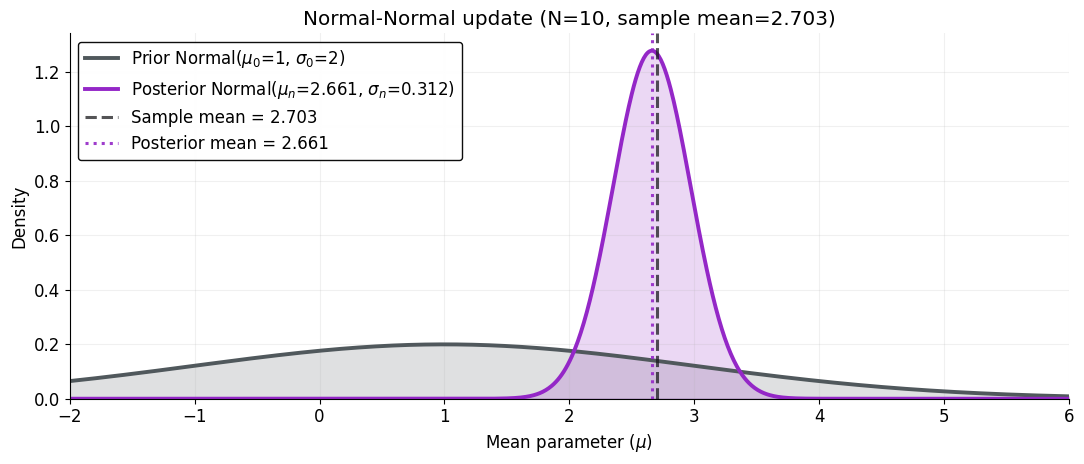

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.8))

prior_color = "#50585C"
post_color  = "#9427C7"
sample_color   = "#1B1B1E" 
pmean_color = "#9427C7"

# plotting prior...
ax.plot(theta_domain, prior_pdf, lw=2.8, color=prior_color, label=fr"Prior Normal($\mu_0$={mu_0:g}, $\sigma_0$={sigma_0:g})")
ax.fill_between(theta_domain, 0, prior_pdf, color=prior_color, alpha=0.18)


# plotting posterior...
ax.plot(theta_domain, post_pdf, lw=2.8, color=post_color, label=fr"Posterior Normal($\mu_n$={mu_post:.3f}, $\sigma_n$={sigma_post:.3f})")
ax.fill_between(theta_domain, 0, post_pdf, color=post_color, alpha=0.18)


ax.axvline(y_mean, color=sample_color, lw=2.2, ls="--", alpha=0.75, label=f"Sample mean = {y_mean:.3f}")
ax.axvline(mu_post, color=pmean_color, lw=2.2, ls=":", alpha=0.9, label=f"Posterior mean = {mu_post:.3f}")


ax.set_xlim(theta_domain.min(), theta_domain.max())
ax.set_ylim(0, None)
ax.set_xlabel(r"Mean parameter ($\mu$)")
ax.set_ylabel("Density")
ax.set_title(f"Normal-Normal update (N={N}, sample mean={y_mean:.3f})")
ax.legend(frameon=True, framealpha=0.95, facecolor="white", edgecolor=(0, 0, 0, 0.12))

fig.tight_layout()
plt.show()


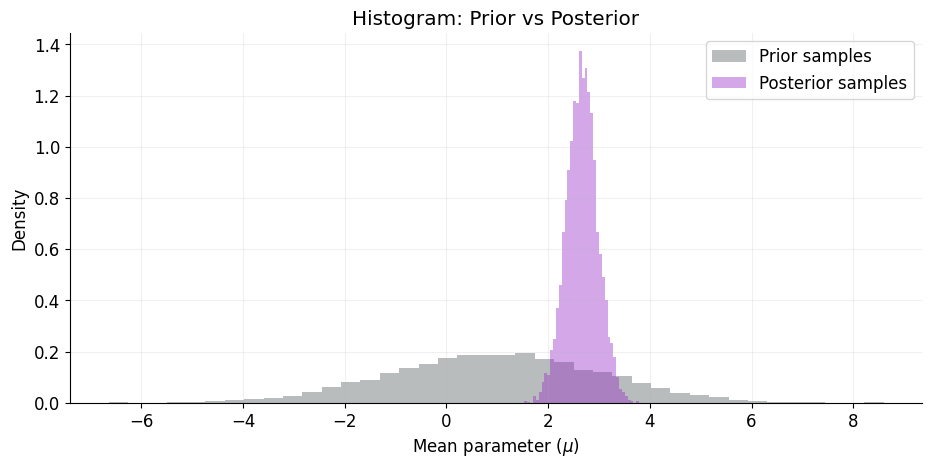

In [16]:
# making prior and posterior histograms...
prior_samples = np.random.normal(mu_0, sigma_0, size=5000)
post_samples  = np.random.normal(mu_post, sigma_post, size=5000)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.hist(prior_samples, bins=40, density=True, alpha=0.4, color=prior_color, label="Prior samples")

ax.hist(post_samples, bins=40, density=True, alpha=0.4, color=post_color, label="Posterior samples")

ax.set_xlabel(r"Mean parameter ($\mu$)")
ax.set_ylabel("Density")
ax.set_title("Histogram: Prior vs Posterior")
ax.legend()

plt.show()